In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import accuracy_score
import pickle
import os
import time

In [ ]:
import pickle   # to use the pickle.load() function that will load the data.
import numpy as np
import os

# Define the function to load each CIFAR-10 batch file

def load_cifar10_batch(filename):
    with open(filename, 'rb') as f:
        data_dict = pickle.load(f, encoding='bytes')
        images = data_dict[b'data']
        labels = data_dict[b'labels']
        images = images.reshape(10000, 3, 32, 32).astype("float")
        return images, labels

In [ ]:
!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
!tar -xvzf cifar-10-python.tar.gz

--2024-11-24 12:24:08--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz.1’

cifar-10-python.tar 100%[===================>] 162.60M  45.9MB/s    in 4.0s    

2024-11-24 12:24:12 (40.8 MB/s) - ‘cifar-10-python.tar.gz.1’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


In [ ]:
data_dir = 'cifar-10-batches-py'

# Initialize empty lists to store training images and labels
train_images, train_labels = [], []

# Load each training batch file (data_batch_1 to data_batch_5)
for i in range(1, 6):
    # Construct the filename for each batch file
    filename = os.path.join(data_dir, f'data_batch_{i}')

    # Load the images and labels from the batch file
    images, labels = load_cifar10_batch(filename)

    # Append the batch data to the lists
    train_images.append(images)
    train_labels += labels
    end = i

 # Concatenate all training batches into a single dataset
train_images = np.concatenate(train_images)
train_labels = np.array(train_labels)

# Load the test batch file (test_batch)
test_images, test_labels = load_cifar10_batch(os.path.join(data_dir, 'test_batch'))

# Reshape arrays for easier usage in neural networks
train_images = train_images.transpose(0, 2, 3, 1)  # Reshape to (num_samples, 32, 32, 3)
test_images = test_images.transpose(0, 2, 3, 1)

In [ ]:
class Layer:

    def __init__(self, input_size, output_size, activation='relu'):
        # Initialize weights and biases
        self.weights = np.random.randn(input_size, output_size) * 0.01
        self.biases = np.zeros((1, output_size))
        self.activation = activation
        self.output = None
        self.input = None

    def forward(self, input_data):
        # Linear transformation
        self.input = input_data
        linear_output = np.dot(input_data, self.weights) + self.biases

        # Apply activation function
        if self.activation == 'relu':
            self.output = np.maximum(0, linear_output)
        elif self.activation == 'softmax':
            exp_vals = np.exp(linear_output - np.max(linear_output, axis=1, keepdims=True))
            self.output = exp_vals / np.sum(exp_vals, axis=1, keepdims=True)
        else:
            raise ValueError("Unsupported activation function")

        return self.output

    def backward(self, d_output, learning_rate):

        # Backward pass to calculate gradients
        if self.activation == 'relu':
            d_linear_output = d_output * (self.output > 0).astype(float)
        elif self.activation == 'softmax':
            # Softmax derivative is handled typically in the loss function (e.g., cross-entropy)
            d_linear_output = d_output
        else:
            raise ValueError("Unsupported activation function")

        # Gradients with respect to weights and biases
        d_weights = np.dot(self.input.T, d_linear_output)
        d_biases = np.sum(d_linear_output, axis=0, keepdims=True)
        d_input = np.dot(d_linear_output, self.weights.T)

        # Update weights and biases
        self.weights -= learning_rate * d_weights
        self.biases -= learning_rate * d_biases

        return d_input  # Return gradient with respect to input, to propagate backward

In [ ]:
class MLP:
    def __init__(self):
        # Define the network layers
        self.layers = [
            Layer(3072, 128, activation='relu'),  # Input layer -> first hidden layer
            #Layer(256, 128, activation='relu'),   # First hidden layer -> second hidden layer    Layer(3072, 512, activation='relu'
            #Layer(1024, 256, activation='relu'),   # Second hidden layer -> third hidden layer        Layer(512, 128, activation='relu')
            Layer(128, 10, activation='softmax')  # Final hidden layer -> output layer                Layer(128, 10, activation='softmax')
        ]

    def forward(self, x):
        # Forward pass through all layers
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, d_output, learning_rate):
        # Backward pass through all layers (in reverse order)
        for layer in reversed(self.layers):
            d_output = layer.backward(d_output, learning_rate)


In [ ]:

def cross_entropy_loss(predictions, targets):
    # Avoid log(0) by adding a small epsilon
    epsilon = 1e-10
    predictions = np.clip(predictions, epsilon, 1. - epsilon)
    N = predictions.shape[0]
    ce_loss = -np.sum(targets * np.log(predictions)) / N

    return ce_loss


In [ ]:
def calculate_accuracy(pred_output, true_output):
    # Make predictions
    predictions = np.argmax(pred_output, axis=1)
    actual = np.argmax(true_output, axis=1)
    # Calculate accuracy
    accuracy = np.mean(predictions == actual)
    return accuracy

In [ ]:
def preprocess_data(images):
    # Normalize the images: scale pixel values to range between 0 and 1
    images = images / 255.0

    # Flatten the images to shape (num_samples, 3072) for an MLP
    images = images.reshape(images.shape[0], -1)

    return images

In [ ]:
def one_hot_encode(labels, num_classes=10):
    """Convert labels to one-hot encoded format."""
    return np.eye(num_classes)[labels]

In [ ]:
# Preprocess the images
train_images = preprocess_data(train_images)
test_images = preprocess_data(test_images)

# One-hot encode the labels
train_labels = one_hot_encode(train_labels)
test_labels = one_hot_encode(test_labels)

In [ ]:
def cross_entropy_loss_gradient(predictions, targets):
    return predictions - targets  # derivative of cross-entropy with softmax

In [ ]:

# Hyperparameters
num_epochs = 50
batch_size = 64
learning_rate = 0.001

# Initialize the MLP model
mlp = MLP()  # my MLP class instance

# starting point to calculate the training time
start_time = time.time()

# Initializing arrays for the plots
loss_values = []
accuracy_values = []
test_accuracy_values = []

# Training loop
for epoch in range(num_epochs):
    epoch_loss = 0  # Track the total loss for the epoch

    # Shuffle the training data for each epoch
    indices = np.arange(len(train_images))
    np.random.shuffle(indices)
    train_images = train_images[indices]
    train_labels = train_labels[indices]

    # Batch processing
    for i in range(0, len(train_images), batch_size):
        # Get a batch of images and labels
        batch_images = train_images[i:i + batch_size]
        batch_labels = train_labels[i:i + batch_size]

        # Forward pass
        predictions = mlp.forward(batch_images)

        # Compute loss
        loss = cross_entropy_loss(predictions, batch_labels)
        epoch_loss += loss

        # Backward pass
        d_loss = cross_entropy_loss_gradient(predictions, batch_labels)
        mlp.backward(d_loss, learning_rate)

    # Calculate and display average loss for this epoch
    avg_epoch_loss = epoch_loss / (len(train_images) // batch_size)
    loss_values.append(avg_epoch_loss)

    # **Calculate Training Accuracy**
    train_predictions = mlp.forward(train_images)
    train_accuracy = calculate_accuracy(train_predictions, train_labels)
    accuracy_values.append(train_accuracy)

    # **Calculate Test Accuracy**
    test_predictions = mlp.forward(test_images)
    test_accuracy = calculate_accuracy(test_predictions, test_labels)
    test_accuracy_values.append(test_accuracy)

    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Loss: {avg_epoch_loss:.4f}, "
        f"Train Accuracy: {train_accuracy:.4f}, "
        f"Test Accuracy: {test_accuracy:.4f}"
    )

print("Training complete!")
end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time} seconds")

Epoch 1/50, Loss: 1.9436, Train Accuracy: 0.3432, Test Accuracy: 0.3407
Epoch 2/50, Loss: 1.7461, Train Accuracy: 0.3958, Test Accuracy: 0.3938
Epoch 3/50, Loss: 1.6675, Train Accuracy: 0.4118, Test Accuracy: 0.4056
Epoch 4/50, Loss: 1.6135, Train Accuracy: 0.4439, Test Accuracy: 0.4353
Epoch 5/50, Loss: 1.5727, Train Accuracy: 0.4449, Test Accuracy: 0.4344
Epoch 6/50, Loss: 1.5393, Train Accuracy: 0.4586, Test Accuracy: 0.4396
Epoch 7/50, Loss: 1.5118, Train Accuracy: 0.4785, Test Accuracy: 0.4566
Epoch 8/50, Loss: 1.4894, Train Accuracy: 0.4725, Test Accuracy: 0.4510
Epoch 9/50, Loss: 1.4644, Train Accuracy: 0.5052, Test Accuracy: 0.4798
Epoch 10/50, Loss: 1.4479, Train Accuracy: 0.4658, Test Accuracy: 0.4429
Epoch 11/50, Loss: 1.4285, Train Accuracy: 0.5140, Test Accuracy: 0.4844
Epoch 12/50, Loss: 1.4163, Train Accuracy: 0.5199, Test Accuracy: 0.4877
Epoch 13/50, Loss: 1.3990, Train Accuracy: 0.5202, Test Accuracy: 0.4784
Epoch 14/50, Loss: 1.3827, Train Accuracy: 0.5300, Test Accu

In [ ]:
def calculate_metrics(pred_output, true_output):
    # Convert the one-hot encoded vectors to class indices
    predictions = np.argmax(pred_output, axis=1)
    actual = np.argmax(true_output, axis=1)

    # Calculate precision, recall, and f1 score for each class
    precision = precision_score(actual, predictions, average=None, labels=np.unique(actual))
    recall = recall_score(actual, predictions, average=None, labels=np.unique(actual))
    f1 = f1_score(actual, predictions, average=None, labels=np.unique(actual))

    return precision, recall, f1

# After training, evaluate on validation data
test_predictions = mlp.forward(test_images)
test_precision, test_recall, test_f1 = calculate_metrics(test_predictions, test_labels)

print("test Precision:", test_precision)
print("test Recall:", test_recall)
print("test F1 Score:", test_f1)

# Print classification report
print("Classification Report:")
#print(classification_report(actual, predictions, target_names=class_names))

Validation Precision: [0.56435644 0.67715618 0.5049505  0.37987988 0.42444261 0.39953271
 0.57240705 0.64588235 0.52039381 0.5814433 ]
Validation Recall: [0.627 0.581 0.306 0.253 0.514 0.513 0.585 0.549 0.74  0.564]
Validation F1 Score: [0.59403126 0.62540366 0.38107098 0.30372149 0.46494799 0.44921191
 0.57863501 0.59351351 0.61106524 0.57258883]
Classification Report:


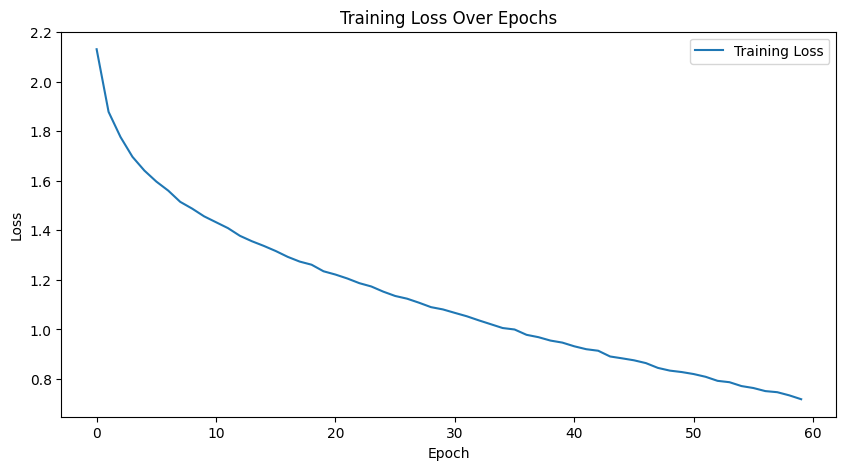

In [ ]:
# Plot loss
plt.figure(figsize=(10, 5))
plt.plot(range(num_epochs), loss_values, label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

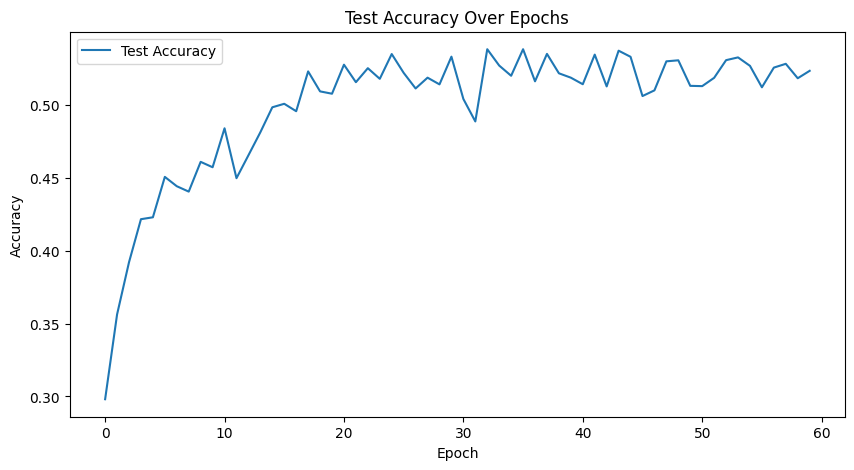

In [ ]:
# Plot accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(num_epochs), test_accuracy_values, label='Test Accuracy')
plt.title('Test Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

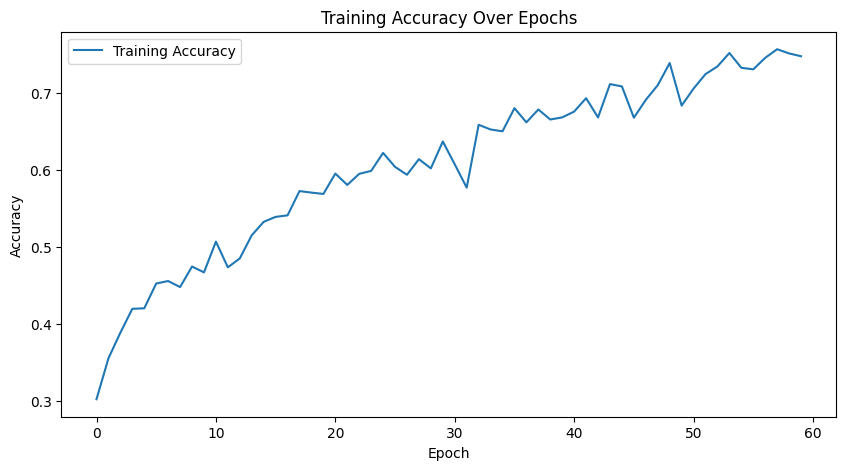

In [ ]:
# Plot accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(num_epochs), accuracy_values, label='Training Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

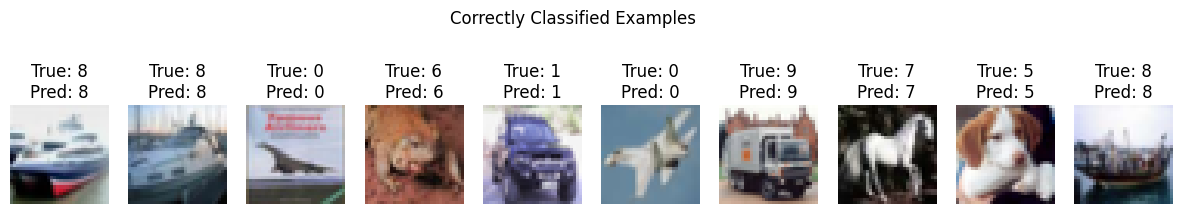

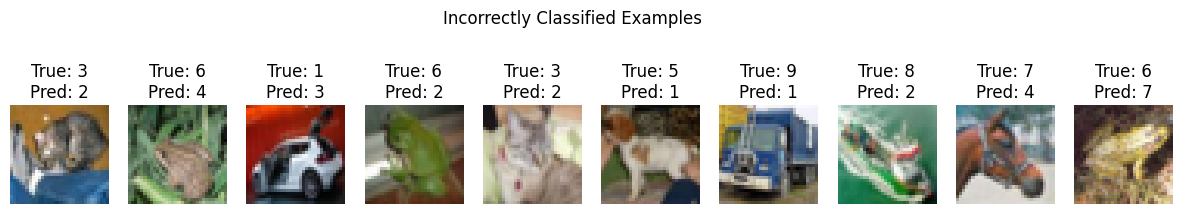

In [ ]:
y_pred = mlp.forward(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert predictions to class indices
y_true = np.argmax(test_labels, axis=1) if test_labels.ndim > 1 else y_test_labels

correct_indices = np.where(y_pred_classes == y_true)[0]
incorrect_indices = np.where(y_pred_classes != y_true)[0]

def plot_examples(indices, title, n=10):
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(indices[:n]):
        plt.subplot(1, n, i + 1)
        # Reshape the image to (32, 32, 3) - assuming it's a 32x32 RGB image
        image = test_images[idx].reshape(32, 32, 3)
        plt.imshow(image)  # Display the reshaped image
        plt.title(f"True: {y_true[idx]}\nPred: {y_pred_classes[idx]}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Plot correct examples
plot_examples(correct_indices, "Correctly Classified Examples")

# Plot incorrect examples
plot_examples(incorrect_indices, "Incorrectly Classified Examples")